In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings(action = 'ignore')

In [16]:
#matplotlib 한글

# 사용할 한글 폰트 지정 - 자기 OS만 # 지우고 쓰기
# font_path = "C:/Windows/Fonts/malgun.ttf"  # Windows
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"  # macOS
# font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # Linux

font_prop = fm.FontProperties(fname=font_path)

# 폰트 적용
plt.rc('font', family=font_prop.get_name())

In [49]:
train = pd.read_csv('csv/train.csv').drop(columns = ['ID'])

In [33]:
features=list(train.columns)
print(features)

['설립연도', '국가', '분야', '투자단계', '직원 수', '인수여부', '상장여부', '고객수(백만명)', '총 투자금(억원)', '연매출(억원)', 'SNS 팔로워 수(백만명)', '기업가치(백억원)', '성공확률']


In [36]:
category_features = ['설립연도','국가','분야','투자단계','기업가치(백억원)']
numeric_features = ['직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)']
bool_features = ['인수여부','상장여부']

for cat in category_features:
    print(train[cat].unique())
    
for cat in bool_features:
    print(train[cat].unique())

[2009 2023 2018 2016 2020 2012 2008 2005 2015 2002 2019 2001 2006 2004
 2021 2011 2013 2003 2014 2017 2010 2022 2007]
['CT005' 'CT006' 'CT007' 'CT002' 'CT008' 'CT010' 'CT001' 'CT009' 'CT003'
 'CT004']
['이커머스' '핀테크' '기술' nan '에듀테크' '게임' '헬스케어' '물류' '푸드테크' 'AI' '에너지']
['Series A' 'Seed' 'Series C' 'Series B' 'IPO']
[nan '2500-3500' '3500-4500' '1500-2500' '4500-6000' '6000이상']
['No' 'Yes']
['No' 'Yes']


In [53]:
# 결측치가 있는 컬럼만 출력
missing_values = train[features].isnull().sum()
print(missing_values[missing_values > 0])

print(-1 in train[numeric_features])

분야            857
직원 수          174
고객수(백만명)     1320
기업가치(백억원)    1220
dtype: int64
False


In [57]:
# 전체 개수 확인
train.count()

설립연도              4376
국가                4376
분야                3519
투자단계              4376
직원 수              4202
인수여부              4376
상장여부              4376
고객수(백만명)          3056
총 투자금(억원)         4376
연매출(억원)           4376
SNS 팔로워 수(백만명)    4376
기업가치(백억원)         3156
성공확률              4376
dtype: int64

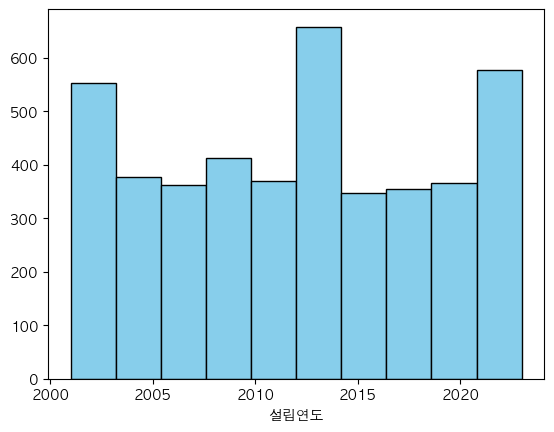

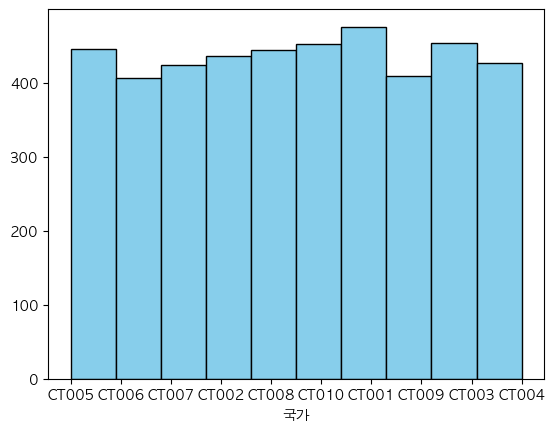

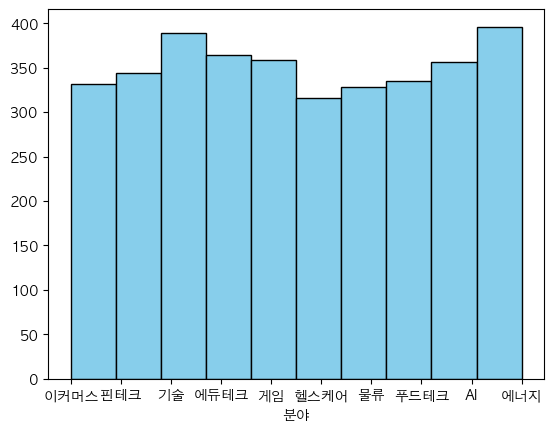

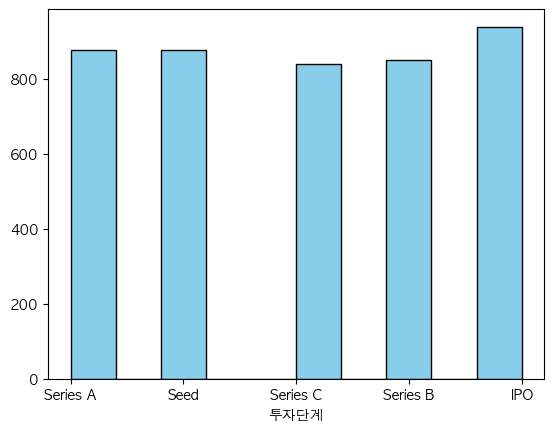

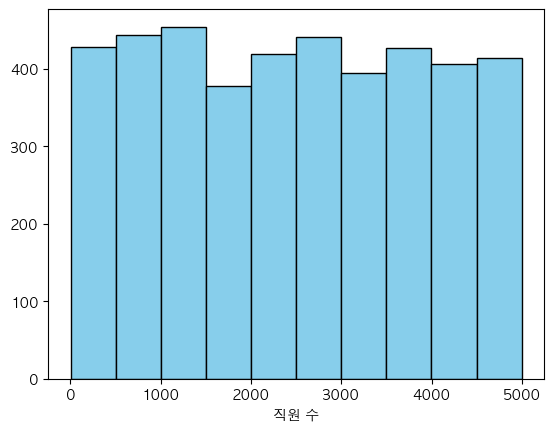

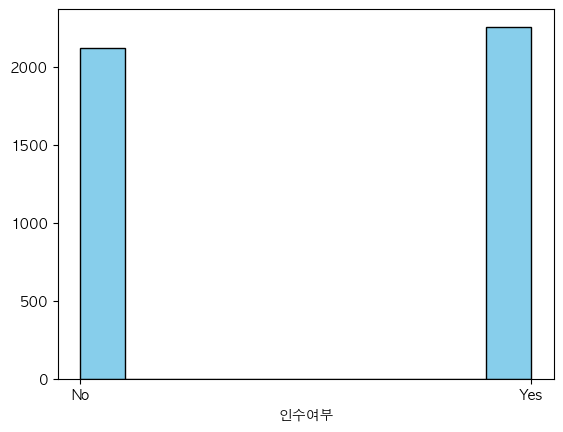

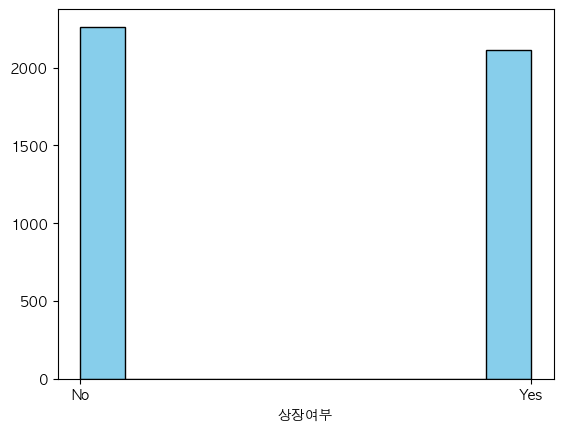

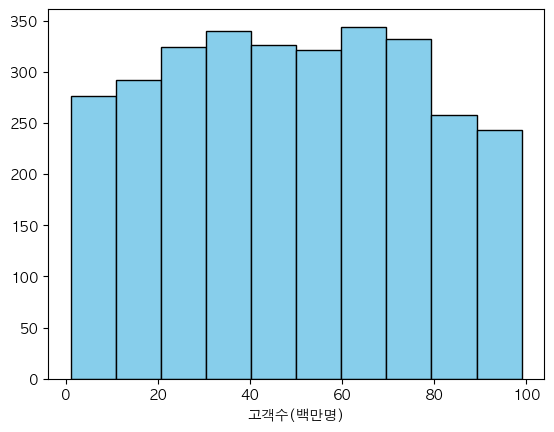

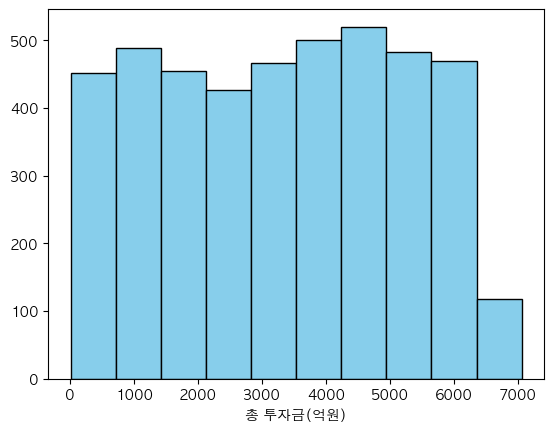

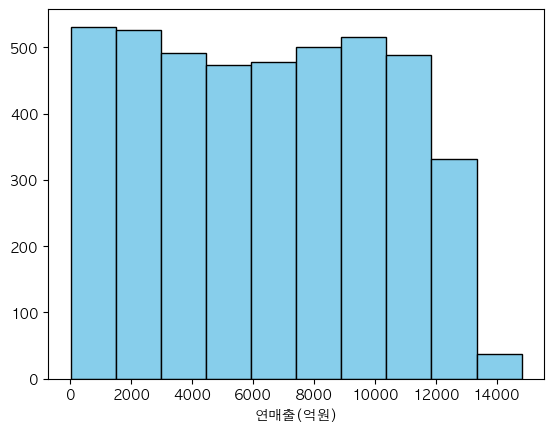

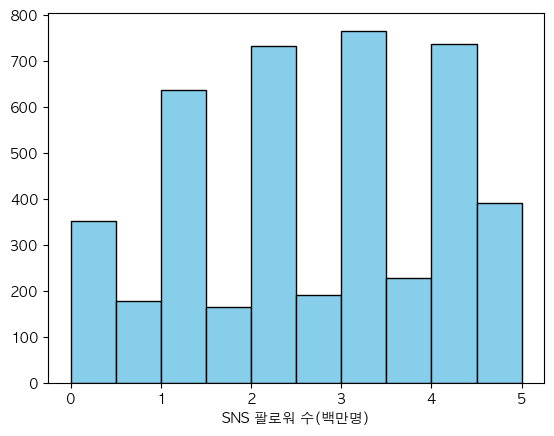

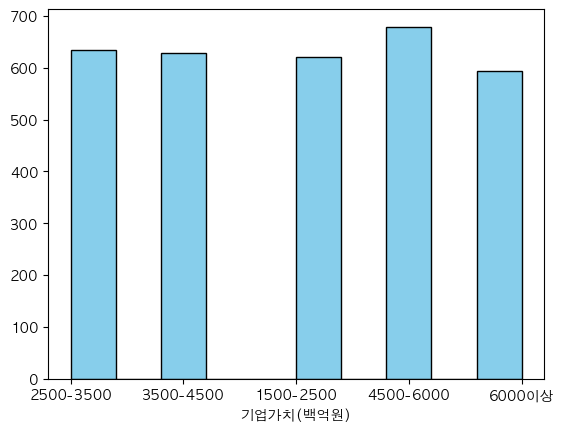

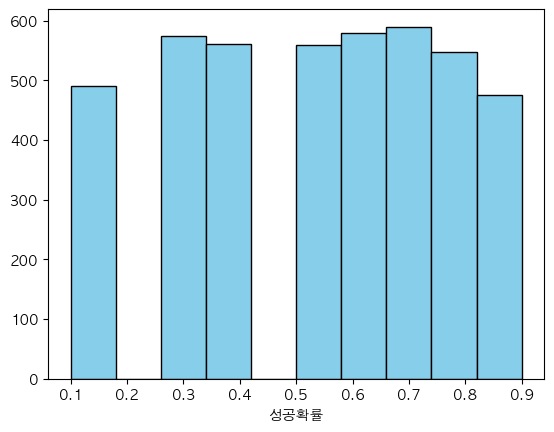

In [77]:
# feature 별 개수 확인 (결측치 제외))

for col in features:
    plt.hist(train[col].dropna(), color='skyblue', edgecolor='black')
    plt.xlabel(f"{col}")

    plt.xticks(fontsize=10)
    plt.show()

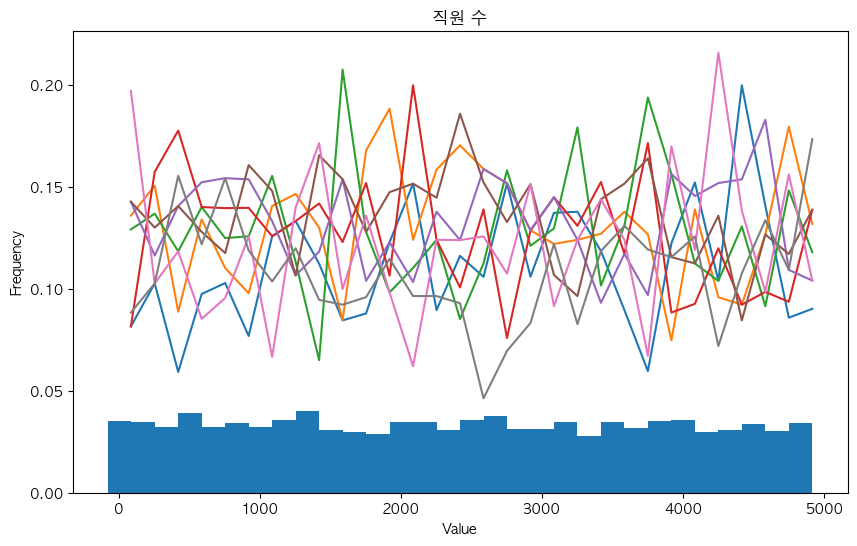

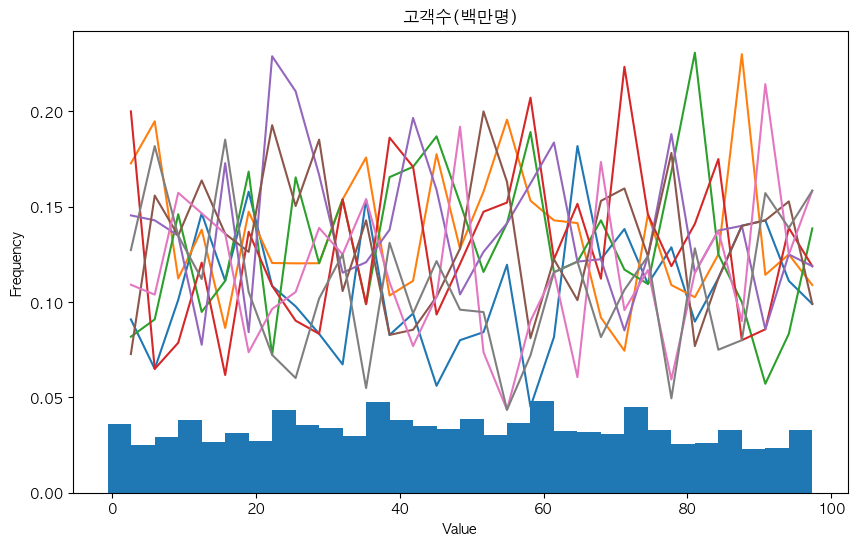

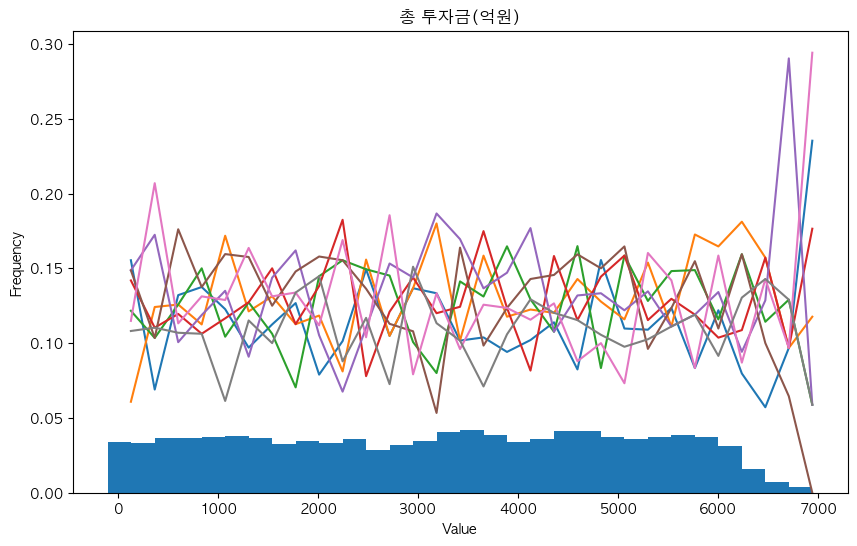

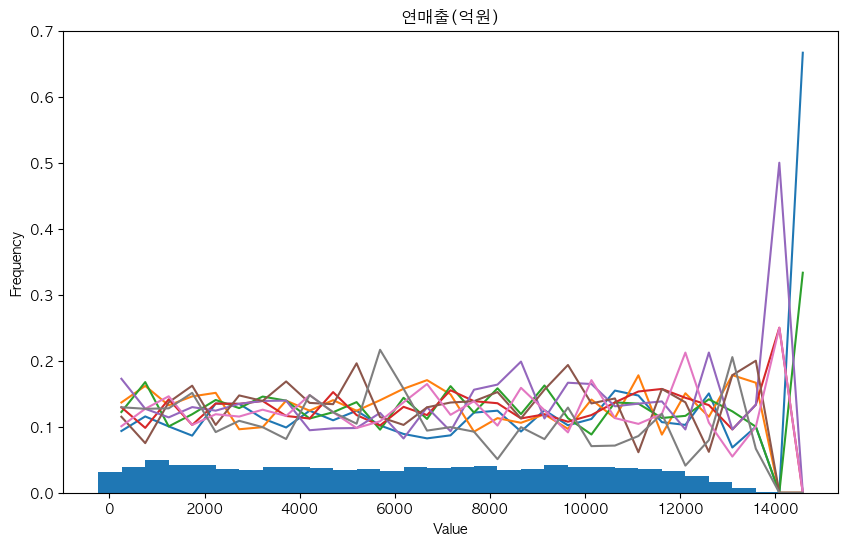

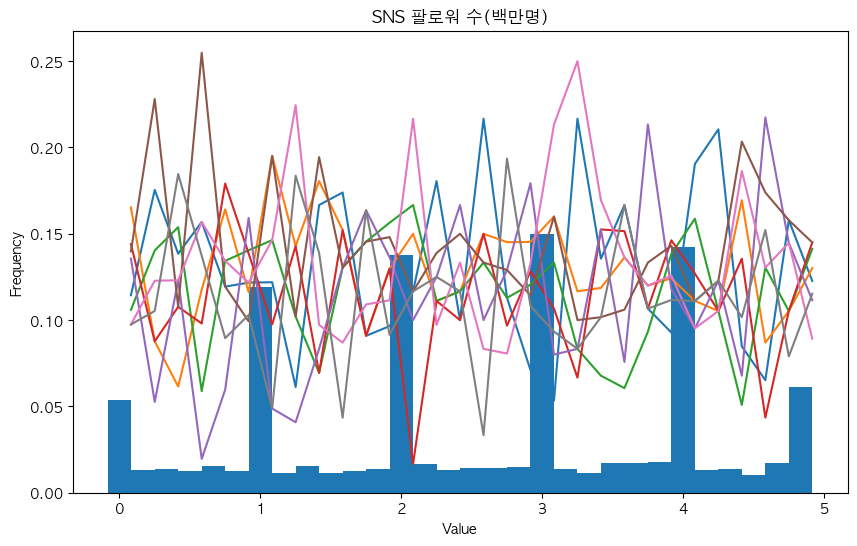

In [74]:
# feature 별 개수 확인 (결측치 제외))

for col in numeric_features:
    train_df=train.copy() #원본 보호
    train_df = train_df.dropna(subset=[col])
    
    train_df['bin']=pd.cut(train_df[col], bins=30)
    
    count_df = train_df.groupby(['bin', '성공확률']).size().unstack(fill_value=0)
    count_df = count_df.div(count_df.sum(axis=1), axis=0)
    
    # 구간 중심값
    count_df['bin_center'] = count_df.index.map(lambda x: x.mid)

    counts, bins = np.histogram(train_df[col], bins=30)
    percent = counts / counts.sum()

    plt.figure(figsize=(10,6))
    
    plt.bar(bins[:-1], percent, width=np.diff(bins))

    for percentage in count_df.columns[:-1]:  # 마지막은 bin_center
        plt.plot(count_df['bin_center'], count_df[percentage], label=percentage)
    
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
#결측치 땜빵

for feature in numeric_features:
    train[feature] = train[feature].fillna(0)
for feature in category_features:
    train[feature] = train[feature].fillna('Missing')